# CONFLUENCE Tutorial: Lumped Basin Workflow (East River)

This notebook walks through a complete workflow for a lumped basin model using the East River as an example. We'll execute each step individually to understand what's happening at each stage.

## Overview of This Tutorial

We'll work through the simplest case in catchment modeling: a lumped basin model. This treats the entire watershed as a single unit, making it an ideal starting point for understanding the CONFLUENCE workflow.

We'll run through:
1. Project setup and configuration
2. Domain definition (watershed delineation)
3. Data acquisition (forcings and attributes)
4. Model preprocessing
5. Model execution
6. Results visualization

## Setup and Import Libraries

In [1]:
# Import required libraries
import sys
import os
from pathlib import Path
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from datetime import datetime
import contextily as cx
import xarray as xr

# Add CONFLUENCE to path
confluence_path = Path('../').resolve()
sys.path.append(str(confluence_path))

# Import main CONFLUENCE class
from CONFLUENCE import CONFLUENCE

# Set up plotting style
plt.style.use('default')
%matplotlib inline

## Initialize CONFLUENCE
Now let's set up our directories and load the configuration. CONFLUENCE uses a centralized configuration file that controls all aspects of the modeling workflow.

In [2]:
# Set directory paths
CONFLUENCE_CODE_DIR = confluence_path
CONFLUENCE_DATA_DIR = Path('/scratch/dlhogan/ess_project_data')  # ← User should modify this path

# Load and update configuration
config_path = CONFLUENCE_CODE_DIR / '0_config_files' / 'config_East_River.yaml'

# Read config file and update paths
with open(config_path, 'r') as f:
    config_dict = yaml.safe_load(f)

# Update paths and settings 
config_dict['CONFLUENCE_CODE_DIR'] = str(CONFLUENCE_CODE_DIR)
config_dict['CONFLUENCE_DATA_DIR'] = str(CONFLUENCE_DATA_DIR)

# Update name and experiment id
config_dict['DOMAIN_NAME'] = 'East_River_lumped'
config_dict['EXPERIMENT_ID'] = 'tutorial_run'
config_dict['EXPERIMENT_TIME_START'] = '2010-01-02 01:00'
config_dict['EXPERIMENT_TIME_END'] = '2024-12-31 23:00'


config_dict['HYDROLOGICAL_MODEL'] = 'SUMMA'

# Save updated config to a temporary file
temp_config_path = CONFLUENCE_CODE_DIR / '0_config_files' / 'config_notebook.yaml'
with open(temp_config_path, 'w') as f:
    yaml.dump(config_dict, f)

# Initialize CONFLUENCE
confluence = CONFLUENCE(temp_config_path)

# Display configuration
print("=== Directory Configuration ===")
print(f"Code Directory: {CONFLUENCE_CODE_DIR}")
print(f"Data Directory: {CONFLUENCE_DATA_DIR}")
print("\n=== Key Configuration Settings ===")
print(f"Domain Name: {confluence.config['DOMAIN_NAME']}")
print(f"Pour Point: {confluence.config['POUR_POINT_COORDS']}")
# print(f"Spatial Mode: {confluence.config['SPATIAL_MODE']}")
print(f"Model: {confluence.config['HYDROLOGICAL_MODEL']}")
print(f"Simulation Period: {confluence.config['EXPERIMENT_TIME_START']} to {confluence.config['EXPERIMENT_TIME_END']}")


18:18:21 │ ============================================================
18:18:21 ● CONFLUENCE Logging Initialized
18:18:21 ● Domain: East_River_lumped
18:18:21 ● Experiment ID: tutorial_run
18:18:21 ● Log Level: INFO
18:18:21 ● Log File: /scratch/dlhogan/ess_project_data/domain_East_River_lumped/_workLog_East_River_lumped/confluence_general_East_River_lumped_20250701_181821.log

18:18:21 │ ============================================================
18:18:21 ● Configuration logged to: /scratch/dlhogan/ess_project_data/domain_East_River_lumped/_workLog_East_River_lumped/config_East_River_lumped_20250701_181821.yaml
18:18:21 ● Initializing CONFLUENCE system
18:18:21 ● Configuration loaded from: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/0_config_files/config_notebook.yaml
18:18:21 ● Initializing VariableHandler for dataset: ERA5 and model: SUMMA
18:18:22 ● CONFLUENCE system initialized successfully
=== Directory Configuration ===
Code Directory: /home/dlhogan/projects/for

## 3. Project Setup - Organizing the Modeling Workflow
The first step in any CONFLUENCE workflow is to establish a well-organized project structure. This might seem trivial, but it's crucial for:

- Maintaining consistency across different experiments
- Ensuring all components can find required files
- Enabling reproducibility
- Facilitating collaboration

In [11]:
# Project Initialization
project_dir = confluence.managers['project'].setup_project()

# Create pour point
pour_point_path = confluence.managers['project'].create_pour_point()

# List created directories
print("\nCreated directories:")
for item in sorted(project_dir.iterdir()):
    if item.is_dir():
        print(f"  📁 {item.name}")

print("\nDirectory purposes:")
print("  📁 shapefiles: Domain geometry (watershed, pour points, river network)")
print("  📁 attributes: Static characteristics (elevation, soil, land cover)")
print("  📁 forcing: Meteorological inputs (precipitation, temperature)")
print("  📁 simulations: Model outputs")
print("  📁 evaluation: Performance metrics and comparisons")
print("  📁 plots: Visualizations")
print("  📁 optimisation: Calibration results")

18:27:19 ● Setting up project for domain: East_River_lumped
18:27:19 ● Project directory created at: /scratch/dlhogan/ess_project_data/domain_East_River_lumped
18:27:20 ● Pour point shapefile created successfully: /scratch/dlhogan/ess_project_data/domain_East_River_lumped/shapefiles/pour_point/East_River_lumped_pourPoint.shp

Created directories:
  📁 _workLog_East_River_lumped
  📁 attributes
  📁 optimisation
  📁 plots
  📁 shapefiles

Directory purposes:
  📁 shapefiles: Domain geometry (watershed, pour points, river network)
  📁 attributes: Static characteristics (elevation, soil, land cover)
  📁 forcing: Meteorological inputs (precipitation, temperature)
  📁 simulations: Model outputs
  📁 evaluation: Performance metrics and comparisons
  📁 plots: Visualizations
  📁 optimisation: Calibration results


## Geospatial Domain Definition and Analysis - Data acquisition 
Before we can delineate the watershed, we need elevation data. CONFLUENCE also acquires soil and land cover data at this stage for later use in the model.

In [23]:
# Acquire attributes
print("Acquiring geospatial attributes (DEM, soil, land cover)...")
# Check if we can reuse data from the default model
default_dem_path = CONFLUENCE_DATA_DIR / 'domain_East_River' / 'attributes' / 'elevation' / 'dem'
default_forcing_path = CONFLUENCE_DATA_DIR / 'domain_East_River' / 'forcing' / 'raw_data'
can_reuse = default_dem_path.exists()
can_reuse_forcing = default_forcing_path.exists()

if can_reuse or can_reuse_forcing:
    import shutil
    
    # Create a function to copy files with name substitution
    def copy_with_name_substitution(src_path, dst_path, old_str='', new_str=''):
        if not src_path.exists():
            return False
            
        # Create destination directory if it doesn't exist
        dst_path.parent.mkdir(parents=True, exist_ok=True)
        
        if src_path.is_dir():
            # Copy entire directory
            if not dst_path.exists():
                dst_path.mkdir(parents=True, exist_ok=True)
                
            # Copy all files with name substitution
            for src_file in src_path.glob('**/*'):
                if src_file.is_file():
                    # Create relative path
                    rel_path = src_file.relative_to(src_path)
                    # Create new filename with substitution
                    new_name = src_file.name.replace(old_str, new_str)
                    # Create destination path
                    dst_file = dst_path / rel_path.parent / new_name
                    # Create parent directories if they don't exist
                    dst_file.parent.mkdir(parents=True, exist_ok=True)
                    # Copy the file
                    shutil.copy2(src_file, dst_file)
            return True
        elif src_path.is_file():
            # Copy single file with name substitution
            new_name = dst_path.name.replace(old_str, new_str)
            dst_file = dst_path.parent / new_name
            dst_file.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src_path, dst_file)
            return True
        
        return False

    print("Found existing geospatial data from default model. Copying and renaming files...")
    
    # Copy and rename DEM and other attribute data
    if can_reuse:
        # Define paths
        src_attr_path = CONFLUENCE_DATA_DIR / 'domain_East_River' / 'attributes'
        dst_attr_path = CONFLUENCE_DATA_DIR / 'domain_East_River_lumped' / 'attributes'
        
        # Copy attributes with name substitution
        copied = copy_with_name_substitution(src_attr_path, dst_attr_path, 'default', 'lumped')
        if copied:
            print("✓ Copied and renamed attribute files from default model")
    
    # Copy and rename forcing data
    if can_reuse_forcing:
        # Define paths
        src_forcing_path = CONFLUENCE_DATA_DIR / 'domain_East_River' / 'forcing' / 'raw_data'
        dst_forcing_path = CONFLUENCE_DATA_DIR / 'domain_East_River_lumped' / 'forcing' / 'raw_data'
         
        # Copy forcing data with name substitution
        copied = copy_with_name_substitution(src_forcing_path, dst_forcing_path, 'default', 'lumped')
        if copied:
            print("✓ Copied and renamed forcing data from default model")
       
    print("The lumped model will use these copied files as a starting point.")
else:
    print("No existing data found from the default model. Will acquire all data from scratch.")

    # Step 2: Geospatial Domain Definition - Data Acquisition
    print("\n=== Step 2: Geospatial Domain Definition - Data Acquisition ===")
    
    # Acquire attributes
    print("Acquiring geospatial attributes (DEM, soil, land cover)...")
    confluence.managers['data'].acquire_attributes()

    # Acquire forcings
    print(f"\nAcquiring forcing data: {confluence.config['FORCING_DATASET']}")
    confluence.managers['data'].acquire_forcings()
    
print("\n✓ Geospatial attributes acquired")

Acquiring geospatial attributes (DEM, soil, land cover)...
Found existing geospatial data from default model. Copying and renaming files...
✓ Copied and renamed attribute files from default model
✓ Copied and renamed forcing data from default model
The lumped model will use these copied files as a starting point.

✓ Geospatial attributes acquired


## Geospatial Domain Definition and Analysis - Delineation 

In [24]:
# Define domain
print(f"\nDelineating watershed using method: {confluence.config['DOMAIN_DEFINITION_METHOD']}")
watershed_path = confluence.managers['domain'].define_domain()

# Check outputs
print("\nDomain definition complete:")
print(f"  - Watershed defined: {watershed_path is not None}")


Delineating watershed using method: lumped
18:38:48 ● Domain definition workflow starting with: lumped
18:38:48 ● Starting lumped watershed delineation for East_River_lumped
18:38:48 ● Error executing command: mpirun -n 1 /scratch/dlhogan/ess_project_data/installs/TauDEM/bin/pitremove -z /scratch/dlhogan/ess_project_data/domain_East_River_lumped/attributes/elevation/dem/domain_East_River_lumped_elv.tif -fel /scratch/dlhogan/ess_project_data/domain_East_River_lumped/shapefiles/tempdir/fel.tif
18:38:48 ● Error details: Command 'mpirun -n 1 /scratch/dlhogan/ess_project_data/installs/TauDEM/bin/pitremove -z /scratch/dlhogan/ess_project_data/domain_East_River_lumped/attributes/elevation/dem/domain_East_River_lumped_elv.tif -fel /scratch/dlhogan/ess_project_data/domain_East_River_lumped/shapefiles/tempdir/fel.tif' returned non-zero exit status 5.
18:38:48 ● Error during TauDEM watershed delineation: Command 'mpirun -n 1 /scratch/dlhogan/ess_project_data/installs/TauDEM/bin/pitremove -z /scr

Fatal error in PMPI_Comm_rank: Invalid communicator, error stack:
PMPI_Comm_rank(111): MPI_Comm_rank(comm=0x65f32c60, rank=0x7ffc676c8928) failed
PMPI_Comm_rank(68).: Invalid communicator
/home/dlhogan/miniconda3/envs/confluence-env/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 748251731.4550606 of field GRU_area of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


18:38:50 ● Domain map saved to /scratch/dlhogan/ess_project_data/domain_East_River_lumped/plots/domain/domain_map.png
18:38:50 ● Domain definition workflow finished

Domain definition complete:
  - Watershed defined: True


## Geospatial Domain Definition and Analysis - Discretisation 

In [25]:
# Discretize domain
print(f"\nCreating HRUs using method: {confluence.config['DOMAIN_DISCRETIZATION']}")
hru_path = confluence.managers['domain'].discretize_domain()

# Check outputs
print("\nDomain definition complete:")
print(f"  - HRUs created: {hru_path is not None}")


Creating HRUs using method: GRUs
18:38:50 ● Discretizing domain using method: GRUs
18:38:50 ● Starting domain discretization using attributes: ['GRUs']

18:38:50 │ Step 1/2: Running single attribute discretization method
18:38:50 ● config domain name East_River_lumped


18:38:50 ● Calculating mean elevation for each HRU
18:38:50 ● GRUs saved as HRUs to /scratch/dlhogan/ess_project_data/domain_East_River_lumped/shapefiles/catchment/East_River_lumped_HRUs_GRUs.shp


/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/utils/geospatial/discretization_utils.py:684: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids_utm = gru_gdf.geometry.centroid
/home/dlhogan/miniconda3/envs/confluence-env/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 748251731.4550606 of field GRU_area of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniconda3/envs/confluence-env/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 748251731.4550606 of field HRU_area of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


18:38:52 ● HRU plot saved to /scratch/dlhogan/ess_project_data/domain_East_River_lumped/plots/catchment/East_River_lumped_HRUs_as_GRUs.png

18:38:52 │ Step 2/2: Sorting catchment shape
18:38:52 ● Sorting catchment shape
18:38:52 ● Catchment shape sorted and saved to /scratch/dlhogan/ess_project_data/domain_East_River_lumped/shapefiles/catchment/East_River_lumped_HRUs_GRUs.shp
18:38:52 ● Domain discretization completed in 2.17 seconds
18:38:52 ● Domain discretization failed - no shapefile created

Domain definition complete:
  - HRUs created: False


/home/dlhogan/miniconda3/envs/confluence-env/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 748251731.4550606 of field GRU_area of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/dlhogan/miniconda3/envs/confluence-env/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 748251731.4550606 of field HRU_area of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(


## Visualize the Delineated Domain
Let's see what our watershed looks like:

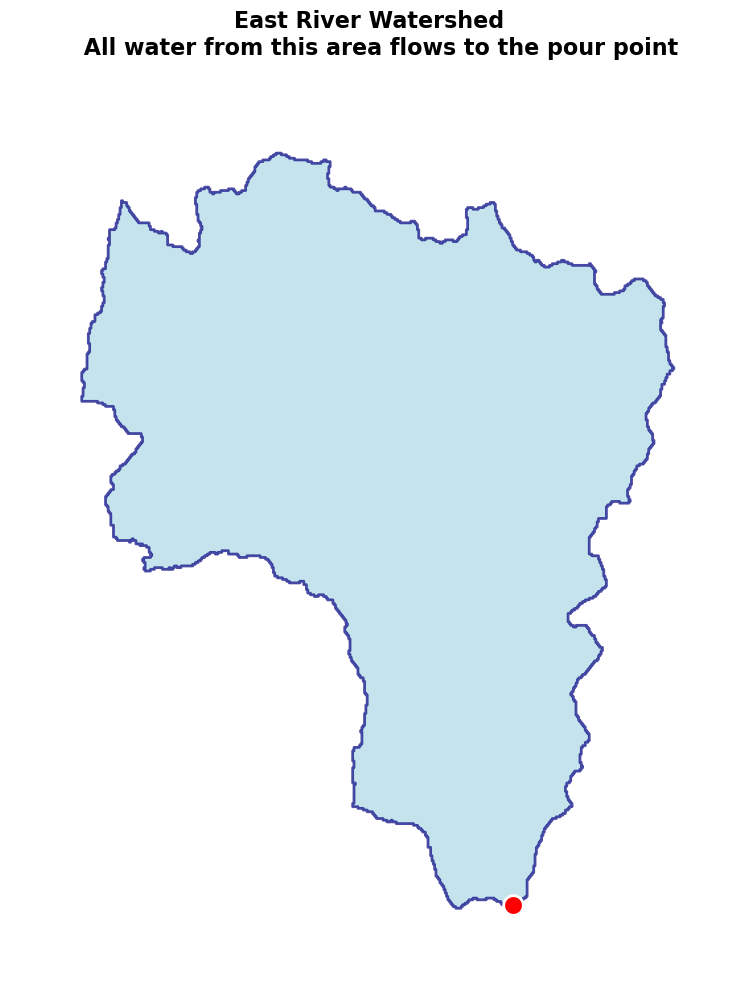

In [26]:
# Visualize the watershed
basin_path = project_dir / 'shapefiles' / 'river_basins'
if basin_path.exists():
    basin_files = list(basin_path.glob('*.shp'))
    
    if basin_files:
        fig, ax = plt.subplots(figsize=(12, 10))
        
        # Load watershed and pour point
        basin_gdf = gpd.read_file(basin_files[0])
        pour_point_gdf = gpd.read_file(pour_point_path)
        
        # Reproject for visualization
        basin_web = basin_gdf.to_crs(epsg=3857)
        pour_web = pour_point_gdf.to_crs(epsg=3857)
        
        # Plot watershed
        basin_web.plot(ax=ax, facecolor='lightblue', edgecolor='navy', 
                       linewidth=2, alpha=0.7)
        
        # Add pour point
        pour_web.plot(ax=ax, color='red', markersize=200, marker='o', 
                      edgecolor='white', linewidth=2, zorder=5)
                
        # Set extent
        minx, miny, maxx, maxy = basin_web.total_bounds
        pad = 5000
        ax.set_xlim(minx - pad, maxx + pad)
        ax.set_ylim(miny - pad, maxy + pad)
        
        ax.set_title('East River Watershed  \n All water from this area flows to the pour point', 
                    fontsize=16, fontweight='bold', pad=20)
        
        ax.axis('off')
        plt.tight_layout()
        plt.show()

## Model Agnostic Data Pre-Processing - Observed data
For a lumped model, the entire watershed becomes a single Hydrologic Response Unit (HRU). This simplification assumes uniform characteristics across the watershed - obviously an approximation, but useful for many applications.


In [27]:
# Model Agnostic Data Pre-Processing
print("Processing observed streamflow data...")
confluence.managers['data'].process_observed_data()

Processing observed streamflow data...
18:38:56 ● Processing observed data
18:38:56 ● Processing USGS streamflow data directly from API
18:38:56 ● Retrieving discharge data for station 09112500
18:38:56 ● Time period: 2010-01-02 to 2025-07-01
18:38:56 ● Converting from cfs to cms using factor: 0.0283168
18:38:56 ● Using formatted start date: 2010-01-02
18:38:56 ● Using formatted end date: 2025-07-01
18:38:56 ● Fetching data from: https://nwis.waterservices.usgs.gov/nwis/iv/?site=09112500&format=rdb&parameterCd=00060&startDT=2010-01-02&endDT=2025-07-01
18:39:10 ● Using discharge column: 211797_00060
18:39:10 ● Using datetime column: datetime


/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/utils/data/data_utils.py:1381: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(io.StringIO(data_str), sep='\t', comment='#')


18:39:11 ● Dropping 2338 rows with non-numeric discharge values
18:39:13 ● Processed streamflow data saved to: /scratch/dlhogan/ess_project_data/domain_East_River_lumped/observations/streamflow/preprocessed/East_River_lumped_streamflow_processed.csv
18:39:13 ● Total rows in processed data: 134324
18:39:13 ● Number of non-null values: 120650
18:39:13 ● Number of null values: 13674
18:39:13 ● Successfully processed USGS data for station 09112500
18:39:13 ● Retrieved 411415 records from 2010-03-06 00:00:00 to 2025-07-01 19:15:00
18:39:13 ● Processing SNOTEL data
18:39:13 ● SNOTEL data processing is disabled in configuration
18:39:13 ● Processing FLUXNET data
18:39:13 ● FLUXNET data processing is disabled in configuration
18:39:13 ● Processing USGS groundwater level data
18:39:13 ● USGS groundwater data processing is disabled in configuration
18:39:13 ● Observed data processing completed successfully


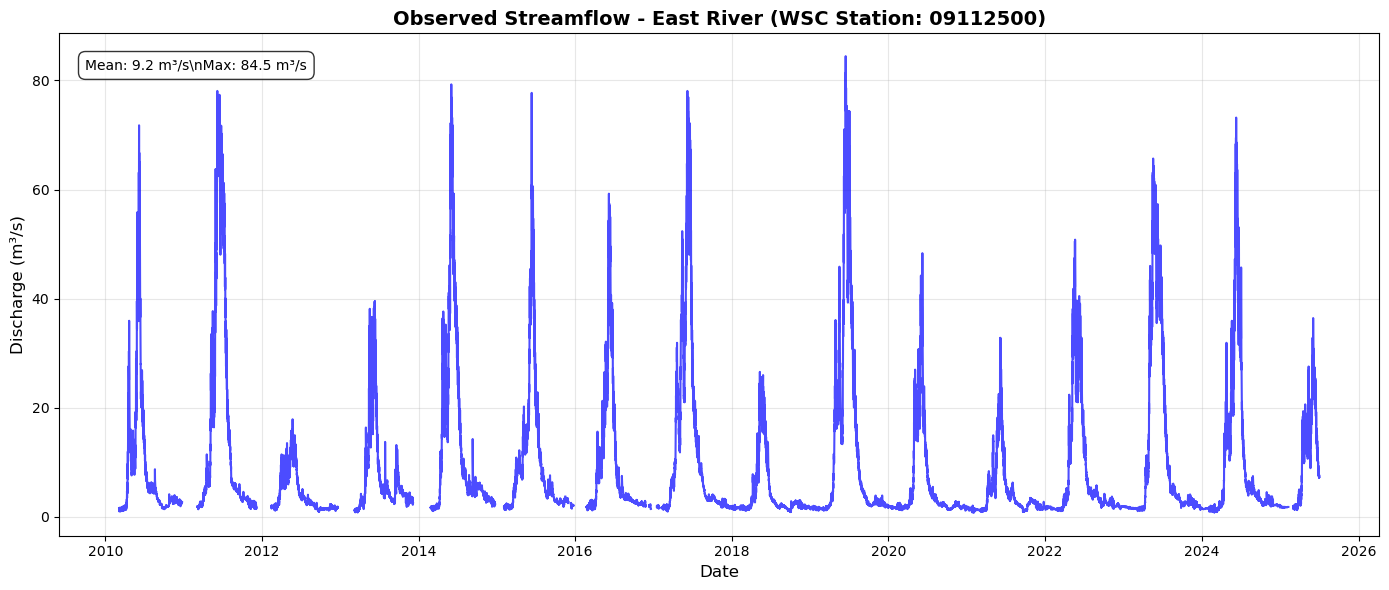

In [28]:
# Visualize observed streamflow data
obs_path = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / 'observations' / 'streamflow' / 'preprocessed' / f"{confluence.config['DOMAIN_NAME']}_streamflow_processed.csv"
if obs_path.exists():
    obs_df = pd.read_csv(obs_path)
    obs_df['datetime'] = pd.to_datetime(obs_df['datetime'])
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(obs_df['datetime'], obs_df['discharge_cms'], 
            linewidth=1.5, color='blue', alpha=0.7)
    
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Discharge (m³/s)', fontsize=12)
    ax.set_title(f'Observed Streamflow - East River (WSC Station: {confluence.config["STATION_ID"]})', 
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    ax.text(0.02, 0.95, f'Mean: {obs_df["discharge_cms"].mean():.1f} m³/s\\nMax: {obs_df["discharge_cms"].max():.1f} m³/s', 
            transform=ax.transAxes, 
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8),
            verticalalignment='top')
    
    plt.tight_layout()
    plt.show()

## 9. Model Agnostic Data Pre-Processing - Forcing data

In [16]:
# Acquire forcings
print(f"\nAcquiring forcing data: {confluence.config['FORCING_DATASET']}")
#confluence.managers['data'].acquire_forcings()


Acquiring forcing data: ERA5


## 10. Model Agnostic Data Pre-Processing - Remapping and zonal statistics

In [17]:
# Run model-agnostic preprocessing
print("\nRunning model-agnostic preprocessing...")
# confluence.managers['data'].run_model_agnostic_preprocessing()


Running model-agnostic preprocessing...


## Model-Specific Preprocessing
Now we prepare inputs specific to our chosen hydrological model (SUMMA in this case). Each model has its own requirements for input format and configuration.

In [36]:
# Model Specific Processing 
print(f"Preparing {confluence.config['HYDROLOGICAL_MODEL']} input files...")
confluence.managers['model'].preprocess_models()

Preparing SUMMA input files...
07:36:03 ● Starting model-specific preprocessing
07:36:03 ● Processing model: SUMMA
07:36:03 ● Starting SUMMA spatial preprocessing
07:36:03 ● Starting memory-efficient temperature lapse rate and data step application
07:36:03 ● Loading topology data...
07:36:03 ● Loaded topology data: 4 rows, 0.05 MB
07:36:03 ● Found 525 forcing files to process
07:36:03 ● Pre-calculating lapse rate corrections...
07:36:06 ● Prepared lapse corrections for 1 HRUs
07:36:06 ● Processing files in batches of 48
07:36:06 ● File East_River_lumped_ERA5_remapped_domain_East_River_ERA5_merged_198001.nc: Could not extract date from filename, using data start date: 1980-01-01 00:00:00
07:36:07 ● File East_River_lumped_ERA5_remapped_domain_East_River_ERA5_merged_198002.nc: Could not extract date from filename, using data start date: 1980-02-01 00:00:00
07:36:07 ● File East_River_lumped_ERA5_remapped_domain_East_River_ERA5_merged_198003.nc: Could not extract date from filename, using 

## Model Instantiation

In [40]:
# Run models
print(f"\nRunning {confluence.config['HYDROLOGICAL_MODEL']} model...")
confluence.managers['model'].run_models()

print("\nModel run complete")


Running SUMMA model...
13:31:17 ● Starting model runs
13:31:17 ● Running model: SUMMA
13:31:17 ● Starting SUMMA run
13:34:01 ● SUMMA run failed with error: Command '/home/dlhogan/MTNHYDROSUMMA/installs/summa/bin/summa.exe -m /scratch/dlhogan/ess_project_data/domain_East_River_lumped/settings/SUMMA/fileManager.txt' returned non-zero exit status 1.
13:34:01 ● Error during SUMMA model run: Command '/home/dlhogan/MTNHYDROSUMMA/installs/summa/bin/summa.exe -m /scratch/dlhogan/ess_project_data/domain_East_River_lumped/settings/SUMMA/fileManager.txt' returned non-zero exit status 1.
13:34:01 ● Traceback (most recent call last):
  File "/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/utils/models/model_manager.py", line 258, in run_models
    getattr(runner, method_name)()
  File "/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/utils/models/summa_utils.py", line 1778, in run_summa
    self.run_summa_serial()
  File "/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro

## Visualisation of results

Let's see how our streamflow hydrograph looks for the default instantiation sof SUMMA

Loading simulated data from: /scratch/dlhogan/ess_project_data/domain_East_River_lumped/simulations/tutorial_run/SUMMA/tutorial_run_timestep.nc
Extracting 'averageRoutedRunoff' variable...
Loading catchment shapefile from: /scratch/dlhogan/ess_project_data/domain_East_River_lumped/shapefiles/river_basins/East_River_lumped_riverBasins_lumped.shp
Catchment area: 748251731.46 m² (748.25 km²)
Converted runoff from m/s to m³/s (multiplied by basin area)
Loading observed streamflow data from: /scratch/dlhogan/ess_project_data/domain_East_River_lumped/observations/streamflow/preprocessed/East_River_lumped_streamflow_processed.csv
Observed data period: 2010-03-06 00:00:00 to 2025-07-01 19:00:00
Observed streamflow range: 0.75 to 84.45 m³/s
Simulated data period: 2010-01-02 00:59:59.999986688 to 2023-09-30 23:00:00.000013312
Simulated streamflow range: 0.14 to 4614.38 m³/s

Common data period: 2010-04-06 00:00:00 to 2023-09-30 00:00:00
Performance metrics:
  - RMSE: 15.87 m³/s
  - NSE: -0.37
  

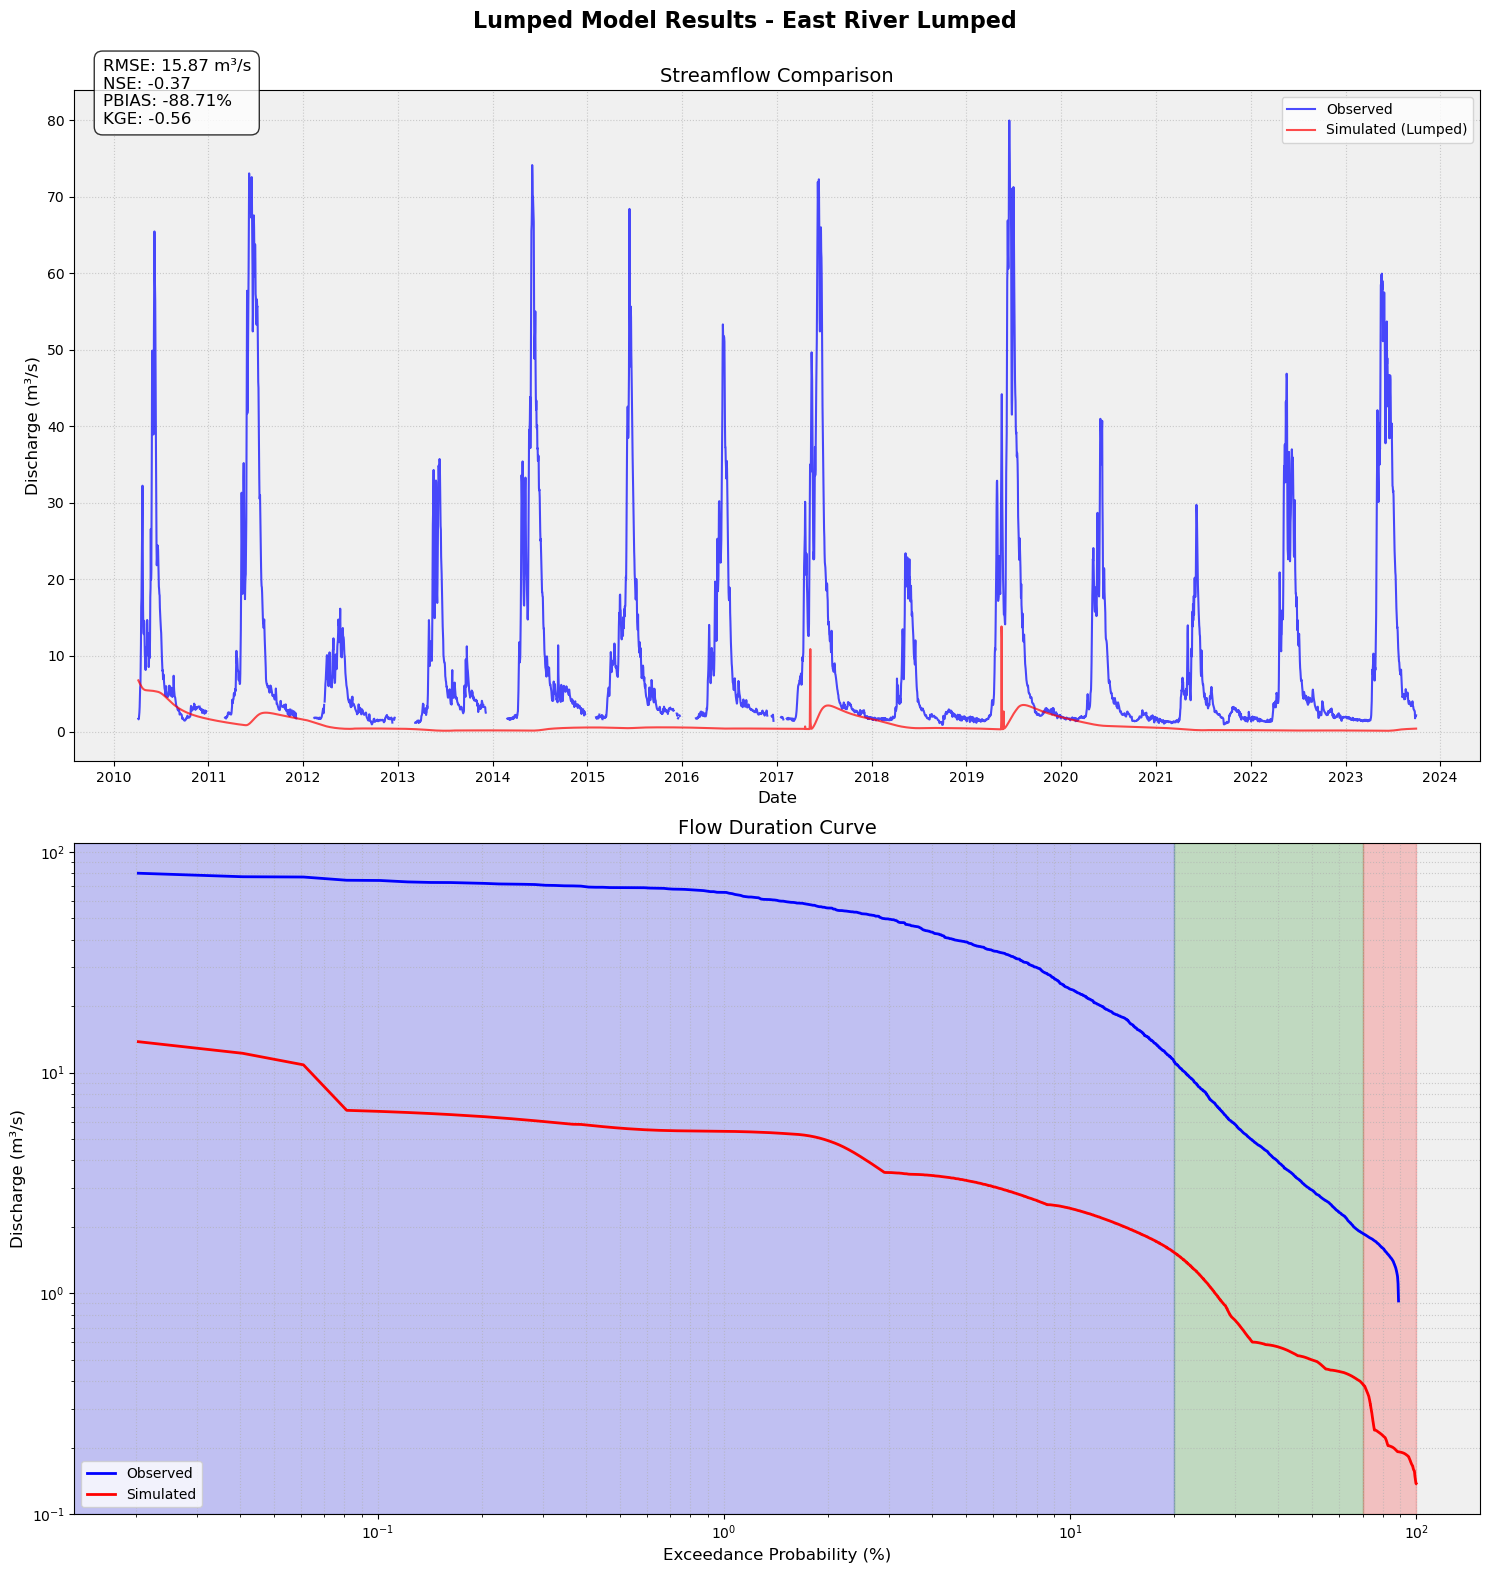


Streamflow visualization complete


In [41]:
# Visualize Observed vs. Simulated Streamflow
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import matplotlib.dates as mdates
import geopandas as gpd
from pathlib import Path

# 1. Load the observed streamflow data - using lumped case approach
obs_path = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / 'observations' / 'streamflow' / 'preprocessed' / f"{confluence.config['DOMAIN_NAME']}_streamflow_processed.csv"
if not obs_path.exists():
    print(f"Warning: Observed streamflow data not found at {obs_path}")
    print("Checking for alternative locations...")
    alt_paths = list(Path(config_dict['CONFLUENCE_DATA_DIR']).glob(f"**/observations/streamflow/preprocessed/*_streamflow_processed.csv"))
    if alt_paths:
        obs_path = alt_paths[0]
        print(f"Found alternative streamflow data at: {obs_path}")
    else:
        print("No observed streamflow data found. Only simulated data will be displayed.")

# 2. Load the simulated streamflow data from SUMMA output - using lumped case approach
sim_path = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / "simulations" / config_dict['EXPERIMENT_ID'] / "SUMMA" / f"{config_dict['EXPERIMENT_ID']}_timestep.nc"

# Check for alternative NetCDF file patterns if not found
if not sim_path.exists():
    print(f"Simulated data not found at {sim_path}")
    print("Checking for alternative NetCDF files...")
    alt_sim_paths = list(Path(config_dict['CONFLUENCE_DATA_DIR']).glob(
        f"domain_{config_dict['DOMAIN_NAME']}/simulations/{config_dict['EXPERIMENT_ID']}/SUMMA/*.nc"))
    
    if alt_sim_paths:
        sim_path = alt_sim_paths[0]
        print(f"Found alternative simulation data at: {sim_path}")
    else:
        raise FileNotFoundError(f"No simulation results found for experiment {config_dict['EXPERIMENT_ID']}")

# Load simulated data
print(f"Loading simulated data from: {sim_path}")
ds = xr.open_dataset(sim_path)

# Extract averageRoutedRunoff
print("Extracting 'averageRoutedRunoff' variable...")
if 'averageRoutedRunoff' in ds:
    # Extract and convert to DataFrame
    sim_runoff = ds['averageRoutedRunoff'].to_dataframe().reset_index()
    
    # Get catchment area from the river basin shapefile to convert from m/s to m³/s
    basin_shapefile = config_dict.get('RIVER_BASINS_NAME', 'default')
    if basin_shapefile == 'default':
        basin_shapefile = f"{config_dict['DOMAIN_NAME']}_riverBasins_{config_dict.get('DOMAIN_DEFINITION_METHOD', 'lumped')}.shp"
    
    basin_path = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / "shapefiles" / "river_basins" / basin_shapefile
    
    try:
        print(f"Loading catchment shapefile from: {basin_path}")
        basin_gdf = gpd.read_file(basin_path)
        area_col = config_dict.get('RIVER_BASIN_SHP_AREA', 'GRU_area')
        
        # Area should be in m²
        if area_col in basin_gdf.columns:
            area_m2 = basin_gdf[area_col].sum()
            print(f"Catchment area: {area_m2:.2f} m² ({area_m2/1e6:.2f} km²)")
            
            # Convert from m/s to m³/s by multiplying by area in m²
            # Assuming first GRU for lumped basin simulation if multiple GRUs exist
            if 'gru' in sim_runoff.columns:
                sim_runoff = sim_runoff[sim_runoff['gru'] == 1][['time', 'averageRoutedRunoff']]
            else:
                sim_runoff = sim_runoff[['time', 'averageRoutedRunoff']]
            
            # Convert units: m/s -> m³/s
            sim_runoff['discharge_cms'] = sim_runoff['averageRoutedRunoff'] * area_m2
            print(f"Converted runoff from m/s to m³/s (multiplied by basin area)")
        else:
            print(f"Warning: Area column '{area_col}' not found in catchment shapefile")
            sim_runoff['discharge_cms'] = sim_runoff['averageRoutedRunoff']  # Use raw values as fallback
    except Exception as e:
        print(f"Error getting basin area: {str(e)}. Using raw values.")
        sim_runoff['discharge_cms'] = sim_runoff['averageRoutedRunoff']  # Use raw values as fallback
    
    # Set index to time for easier processing
    sim_runoff.set_index('time', inplace=True)
    sim_df = sim_runoff[['discharge_cms']]
else:
    print("Warning: 'averageRoutedRunoff' variable not found in the SUMMA output")
    print("Available variables:", list(ds.data_vars))
    raise ValueError("Required 'averageRoutedRunoff' variable not found in SUMMA output")

# Load observed data
obs_df = None
if obs_path.exists():
    print(f"Loading observed streamflow data from: {obs_path}")
    obs_df = pd.read_csv(obs_path)
    obs_df['datetime'] = pd.to_datetime(obs_df['datetime'])
    obs_df.set_index('datetime', inplace=True)
    print(f"Observed data period: {obs_df.index.min()} to {obs_df.index.max()}")
    print(f"Observed streamflow range: {obs_df['discharge_cms'].min():.2f} to {obs_df['discharge_cms'].max():.2f} m³/s")

# Show simulated data info
print(f"Simulated data period: {sim_df.index.min()} to {sim_df.index.max()}")
print(f"Simulated streamflow range: {sim_df['discharge_cms'].min():.2f} to {sim_df['discharge_cms'].max():.2f} m³/s")

# Visualization using distributed case approach
if obs_df is not None:
    # Ensure same frequency for both datasets
    obs_daily = obs_df.resample('D').mean()  # Daily mean if multiple obs per day
    sim_daily = sim_df.resample('D').mean()  # Daily mean if sub-daily sim data
    
    # Find common date range
    start_date = max(obs_daily.index.min(), sim_daily.index.min())
    end_date = min(obs_daily.index.max(), sim_daily.index.max())
    
    # Advance start date by 1 month to skip initial spinup
    start_date = start_date + pd.DateOffset(months=1)
    
    print(f"\nCommon data period: {start_date} to {end_date}")
    
    # Filter to common period
    obs_period = obs_daily.loc[start_date:end_date]
    sim_period = sim_daily.loc[start_date:end_date]
    
    # Calculate performance metrics
    # Calculate root mean square error (RMSE)
    rmse = np.sqrt(((obs_period['discharge_cms'] - sim_period['discharge_cms'])**2).mean())
    
    # Calculate Nash-Sutcliffe Efficiency (NSE)
    mean_obs = obs_period['discharge_cms'].mean()
    numerator = ((obs_period['discharge_cms'] - sim_period['discharge_cms'])**2).sum()
    denominator = ((obs_period['discharge_cms'] - mean_obs)**2).sum()
    nse = 1 - (numerator / denominator)
    
    # Calculate Percent Bias (PBIAS)
    pbias = 100 * (sim_period['discharge_cms'].sum() - obs_period['discharge_cms'].sum()) / obs_period['discharge_cms'].sum()
    
    # Calculate Kling-Gupta Efficiency (KGE)
    r = obs_period['discharge_cms'].corr(sim_period['discharge_cms'])  # Correlation
    alpha = sim_period['discharge_cms'].std() / obs_period['discharge_cms'].std()  # Relative variability
    beta = sim_period['discharge_cms'].mean() / obs_period['discharge_cms'].mean()  # Bias ratio
    kge = 1 - ((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)**0.5
    
    print(f"Performance metrics:")
    print(f"  - RMSE: {rmse:.2f} m³/s")
    print(f"  - NSE: {nse:.2f}")
    print(f"  - PBIAS: {pbias:.2f}%")
    print(f"  - KGE: {kge:.2f}")
    
    # Create figure with two subplots for time series and flow duration curve - using distributed case style
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 16))
    fig.suptitle(f"Lumped Model Results - {confluence.config['DOMAIN_NAME'].replace('_', ' ').title()}", 
                 fontsize=16, fontweight='bold')
    
    # Plot time series
    ax1.plot(obs_period.index, obs_period['discharge_cms'], 
             'b-', label='Observed', linewidth=1.5, alpha=0.7)
    ax1.plot(sim_period.index, sim_period['discharge_cms'], 
             'r-', label='Simulated (Lumped)', linewidth=1.5, alpha=0.7)
        
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Discharge (m³/s)', fontsize=12)
    ax1.set_title('Streamflow Comparison', fontsize=14)
    ax1.legend(loc='upper right', fontsize=10)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.set_facecolor('#f0f0f0')
    
    # Format x-axis
    ax1.xaxis.set_major_locator(mdates.YearLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    # Add metrics as text
    ax1.text(0.02, 0.95, 
             f"RMSE: {rmse:.2f} m³/s\nNSE: {nse:.2f}\nPBIAS: {pbias:.2f}%\nKGE: {kge:.2f}",
             transform=ax1.transAxes, 
             fontsize=12,
             bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
    
    # Plot flow duration curve
    # Sort values in descending order
    obs_sorted = obs_period['discharge_cms'].sort_values(ascending=False)
    sim_sorted = sim_period['discharge_cms'].sort_values(ascending=False)
    
    # Calculate exceedance probabilities
    obs_ranks = np.arange(1., len(obs_sorted) + 1) / len(obs_sorted)
    sim_ranks = np.arange(1., len(sim_sorted) + 1) / len(sim_sorted)
    
    # Plot Flow Duration Curves
    ax2.loglog(obs_ranks * 100, obs_sorted, 'b-', label='Observed', linewidth=2)
    ax2.loglog(sim_ranks * 100, sim_sorted, 'r-', label='Simulated', linewidth=2)
    
    ax2.set_xlabel('Exceedance Probability (%)', fontsize=12)
    ax2.set_ylabel('Discharge (m³/s)', fontsize=12)
    ax2.set_title('Flow Duration Curve', fontsize=14)
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, which='both', linestyle=':', alpha=0.6)
    ax2.set_facecolor('#f0f0f0')
    
    # Add flow regime regions
    ax2.axvspan(0, 20, alpha=0.2, color='blue', label='High Flows')
    ax2.axvspan(20, 70, alpha=0.2, color='green', label='Medium Flows')
    ax2.axvspan(70, 100, alpha=0.2, color='red', label='Low Flows')
    
    # Save the plot to file
    plot_folder = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / "plots" / "results"
    plot_folder.mkdir(parents=True, exist_ok=True)
    plot_filename = plot_folder / f"{confluence.config['EXPERIMENT_ID']}_streamflow_comparison.png"
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"Plot saved to: {plot_filename}")
    
    plt.show()
else:
    # If no observations, just plot simulation
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(sim_df.index, sim_df['discharge_cms'], 
            color='red', linewidth=1.5, label='Simulated (Lumped)')
    
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Discharge (m³/s)', fontsize=12)
    ax.set_title(f'Lumped Model Results - {confluence.config["DOMAIN_NAME"].replace("_", " ").title()}', 
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Close the dataset
ds.close()

print("\nStreamflow visualization complete")

In [ ]:
sim_path = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / "simulations" / config_dict['EXPERIMENT_ID'] / "SUMMA" / f"{config_dict['EXPERIMENT_ID']}_day.nc"

ds = xr.open_dataset(sim_path)


<xarray.Dataset> Size: 278kB
Dimensions:                   (time: 6939, hru: 1, gru: 1)
Coordinates:
  * time                      (time) datetime64[ns] 56kB 2004-01-02 ... 2022-...
  * hru                       (hru) int64 8B 1
  * gru                       (gru) int64 8B 1
Data variables:
    SWRadAtm                  (time, hru) float64 56kB ...
    scalarSWE                 (time, hru) float64 56kB ...
    scalarGroundSnowFraction  (time, hru) float64 56kB ...
    scalarTotalRunoff         (time, hru) float64 56kB ...
    hruId                     (hru) int64 8B ...
    gruId                     (gru) int64 8B ...
Attributes: (12/32)
    summaVersion:     undefined
    buildTime:        Mon Jun  9 22:42:43 PDT 2025
    gitBranch:        main-0-g3ec737a
    gitHash:          3ec737a45820464382b28aa1171ca56d5db7f7ef
    soilCatTbl:       ROSETTA
    vegeParTbl:       MODIFIED_IGBP_MODIS_NOAH
    ...               ...
    snowLayers:       CLM_2010
    compaction:       anderson
    thCondSnow:       jrdn1991
    thCondSoil:       funcSoilWet
    spatial_gw:       localColumn
    subRouting:       timeDlay

## 13. Optional Steps - Optimization and Analysis

In [ ]:
# Step 5 & 6: Optional Steps (Optimization and Analysis)
print("=== Step 5 & 6: Optional Steps ===")


## Alternative - Run Complete Workflow

In [ ]:
# Alternative: Run the complete workflow in one step
# (Uncomment to use this instead of the step-by-step approach)

# confluence.run_workflow()

## Summary: Understanding the CONFLUENCE Workflow
Congratulations! You've completed a full lumped basin modeling workflow with CONFLUENCE. 
